In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
dataset_path = ("/content/drive/MyDrive/GET324_Project/    Dataset")

In [ ]:
print(train_generator.class_indices)

{'Other': 0, 'potato_healthy': 1, 'potato_late_blight': 2}


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
        validation_split=0.2,
            rotation_range=20,
                zoom_range=0.2,
                    width_shift_range=0.2,
                        height_shift_range=0.2,
                            horizontal_flip=True,
                                fill_mode='nearest'
                                )

train_generator = train_datagen.flow_from_directory(
                                    dataset_path,
                                        target_size=IMG_SIZE,
                                            batch_size=BATCH_SIZE,
                                                class_mode='categorical',
                                                    subset='training',
                                                        shuffle=True
                                                        )

validation_generator = train_datagen.flow_from_directory(
                                                          dataset_path,
                                                                target_size=IMG_SIZE,
                                                                    batch_size=BATCH_SIZE,
                                                                        class_mode='categorical',
                                                                            subset='validation',
                                                                                shuffle=False
                                                                                )

print(train_generator.class_indices)

Found 279 images belonging to 3 classes.
Found 69 images belonging to 3 classes.
{'Other': 0, 'potato_healthy': 1, 'potato_late_blight': 2}


In [ ]:
model = Sequential([
      Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
          MaxPooling2D(2,2),

              Conv2D(64, (3,3), activation='relu'),
                  MaxPooling2D(2,2),

                      Conv2D(128, (3,3), activation='relu'),
                          MaxPooling2D(2,2),

                              Flatten(),

                                  Dense(128, activation='relu'),
                                      Dropout(0.5),

                                          Dense(3, activation='softmax')
                                          ])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
      optimizer='adam',
          loss='categorical_crossentropy',
              metrics=['accuracy']
              )

In [ ]:
early_stop = EarlyStopping(
      monitor='val_loss',
          patience=5,
              restore_best_weights=True
              )

history = model.fit(
                  train_generator,
                      validation_data=validation_generator,
                          epochs=30,
                              callbacks=[early_stop]
                              )

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9068 - loss: 0.2431 - val_accuracy: 0.8406 - val_loss: 0.3375
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 588ms/step - accuracy: 0.8423 - loss: 0.4347 - val_accuracy: 0.8841 - val_loss: 0.2860
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 577ms/step - accuracy: 0.8817 - loss: 0.3305 - val_accuracy: 0.8551 - val_loss: 0.2657
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 791ms/step - accuracy: 0.8746 - loss: 0.3105 - val_accuracy: 0.8841 - val_loss: 0.3212
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 582ms/step - accuracy: 0.8710 - loss: 0.3160 - val_accuracy: 0.8841 - val_loss: 0.2687
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 592ms/step - accuracy: 0.8710 - loss: 0.2985 - val_accuracy: 0.9275 - val_loss: 0.2471
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 708ms/step - accuracy: 0.9104 - loss: 0.2461 - val_accuracy: 0.9130 - val_loss: 0.2556
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 560ms/step - accuracy: 0.8889 - loss: 0.2869 - val_accuracy: 0.8406 - val_loss: 

In [ ]:
loss, accuracy = model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 259ms/step - accuracy: 0.8551 - loss: 0.3051
Validation Loss: 0.3051
Validation Accuracy: 0.8551


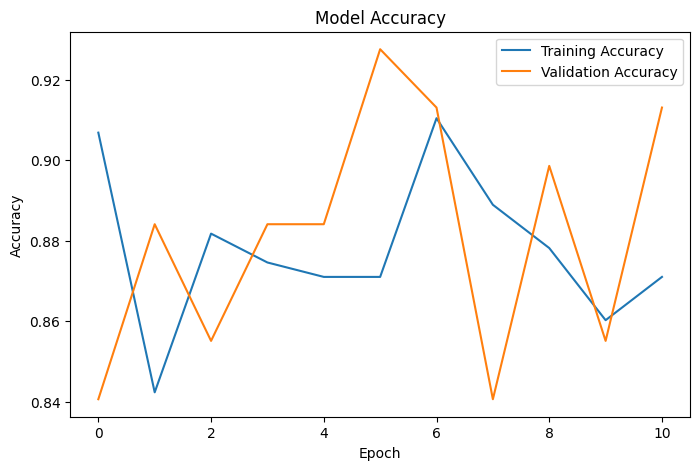

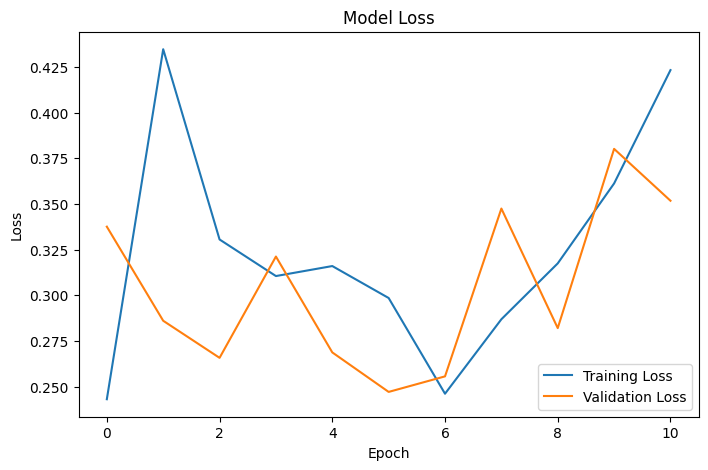

In [ ]:
# Plot Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(validation_generator)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 269ms/step - accuracy: 0.8841 - loss: 0.2934
Validation Loss: 0.2934
Validation Accuracy: 0.8841


In [ ]:
print(train_generator.class_indices)
print(train_generator.samples)
print(validation_generator.samples)

{'Other': 0, 'potato_healthy': 1, 'potato_late_blight': 2}
279
69


In [ ]:
model.save("/content/drive/MyDrive/GET324_Project/Model.keras")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
Prediction: potato_late_blight
Confidence: 70.44%


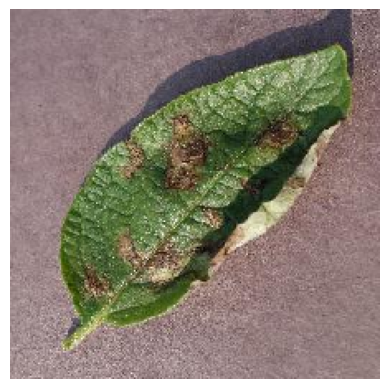

In [ ]:
from tensorflow.keras.preprocessing import image
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = tf.keras.models.load_model("/content/drive/MyDrive/GET324_Project/Model.keras")

    # Image path
img_path = ("/content/drive/MyDrive/GET324_Project/    Dataset/potato_late_blight/053c5330-129d-4515-84da-82a701710723___RS_LB 4576.JPG")

    # Load image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

    # Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
confidence = np.max(prediction) * 100

    # Class names (must match train_generator.class_indices)
classes = ['Other', 'potato_healthy', 'potato_late_blight']

plt.imshow(img)
plt.axis("off")

print(f"Prediction: {classes[predicted_class]}")
print(f"Confidence: {confidence:.2f}%")

In [ ]:
%%writefile app.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import os
import gdown

# Model file name
MODEL_PATH = "potato_leaf_classifier.keras"

# Download model from Google Drive if it doesn't exist
if not os.path.exists(MODEL_PATH):
    gdown.download(
            url="https://drive.google.com/uc?id=12kI2BxRjwXb0sNryp58X5Z8MQeuULDdu",
                    output=MODEL_PATH,
                            quiet=False)
model = tf.keras.models.load_model(MODEL_PATH)

# Class labels (must match the training order)
CLASS_NAMES = ["Other", "potato_healthy", "potato_late_blight"]

# Streamlit page configuration
st.set_page_config(page_title="Potato Leaf Disease Classifier")

# App title
st.title("🥔 Potato Leaf Disease Classifier")
st.write(
    "Upload an image of a potato leaf to determine whether it is Healthy, "
        "affected by Late Blight, or not a potato leaf.")
uploaded_file = st.file_uploader(
      "Choose an image",
          type=["jpg", "jpeg", "png"]
          )
if uploaded_file is not None:
  image = Image.open(uploaded_file).convert("RGB")

  st.image(image, caption="Uploaded Image", use_container_width=True)
  image = image.resize((224, 224))
  img_array = np.array(image) / 255.0
  img_array = np.expand_dims(img_array, axis=0)

              # Make prediction
  prediction = model.predict(img_array)
  predicted_class = np.argmax(prediction)
  confidence = np.max(prediction) * 100

  st.write(f"### Confidence: {confidence:.2f}%")
  if CLASS_NAMES[predicted_class] == "potato_healthy":
    st.success("✅ Healthy Potato Leaf")

  elif CLASS_NAMES[predicted_class] == "potato_late_blight":
    st.error("🍂 Potato Late Blight Detected")

  else:
    st.warning("⚠️ Neither Healthy Potato nor Potato Late Blight (Not a Potato Leaf)")

Writing app.py


In [ ]:
!ls

app.py	drive  sample_data


In [ ]:
%%writefile requirements.txt

streamlit
tensorflow
numpy
Pillow
gdown
h5py

Writing requirements.txt


In [ ]:
!ls

app.py	drive  requirements.txt  sample_data


In [7]:
%%writefile README.md
# 🥔 Potato Leaf Disease Classifier

## Overview
This project is a Convolutional Neural Network (CNN) application developed for the GET 324 Mini Project. It classifies uploaded images into one of three categories:

- Healthy Potato
- Potato Late Blight
- Other (Not a Potato Leaf)

The model was built using TensorFlow/Keras and deployed with Streamlit.

## Features
- Upload potato leaf images.
- Detect Healthy Potato leaves.
- Detect Potato Late Blight.
- Identify images that are not potato leaves.
- Display prediction confidence.

## Project Structure

```text
.
├── app.py
├── requirements.txt
└── README.md
```

## Technologies Used
- Python
- TensorFlow/Keras
- Streamlit
- NumPy
- Pillow
- gdown

## Installation

Clone the repository:

```bash
git clone https://github.com/YOUR_USERNAME/YOUR_REPOSITORY.git
cd YOUR_REPOSITORY
```

Install the required packages:

```bash
pip install -r requirements.txt
```

Run the application:

```bash
streamlit run app.py
```

## Model
The trained model is hosted on Google Drive and is downloaded automatically using **gdown** when the application starts.

## How to Use
1. Open the Streamlit application.
2. Upload a JPG, JPEG, or PNG image.
3. Wait for the prediction.
4. The application displays:
   - ✅ Healthy Potato Leaf
      - 🍂 Potato Late Blight
         - ⚠️ Neither Healthy Potato nor Potato Late Blight (Other)
         5. The confidence score is also displayed.

         ## Dataset
         The model was trained using potato leaf images belonging to three classes:
         - Other
         - Healthy Potato
         - Potato Late Blight

         ## Author
         **Ezekiel Effiong**

         Department of Agricultural and Biosystems Engineering

         University of Uyo

         GET 324 – Cloud Computing and AI Model Deployment for Engineering Applications

Writing README.md
